# Classification and Captioning Aircraft Damage Using Pretrained Models (VGG16)


## **Introduction**

In this project, you will classify aircraft damage using a pre-trained VGG16 model and generate captions using a Transformer-based pretrained model.

## **Project Overview**

Aircraft damage detection is essential for maintaining the safety and longevity of aircraft. Traditional manual inspection methods are time-consuming and prone to human error. This project aims to automate the classification of aircraft damage into two categories: "dent" and "crack." For this, we will utilize feature extraction with a pre-trained VGG16 model to classify the damage from aircraft images. Additionally, we will use a pre-trained Transformer model to generate captions and summaries for the images.

## **Aim of the Project**

The goal of this project is to develop an automated model that accurately classifies aircraft damage from images. By the end of the project, you will have trained and evaluated a model that utilizes feature extraction from VGG16 for damage classification. This model will be applicable in real-world damage detection within the aviation industry. Furthermore, the project will showcase how we can use a Transformer-based model to caption and summarize images, providing a detailed description of the damage.

## **Final Output**

- A trained model capable of classifying aircraft images into "dent" and "crack" categories, enabling automated aircraft damage detection.
- A Transformer-based model that generates captions and summaries of images


## Objectives

After you complete the project, you will be able to:

- Use the VGG16 model for image classification.
- Prepare and preprocess image data for a machine learning task.
- Evaluate the model’s performance using appropriate metrics.
- Visualize model predictions on test data.
- Use a custom Keras layer. 


 ### Task List
To achieve the above objectives, you will complete the following tasks:

- Task 1: Create a `valid_generator` using the `valid_datagen` object
- Task 2: Create a `test_generator` using the `test_datagen` object
- Task 3: Load the VGG16 model
- Task 4: Compile the model
- Task 5: Train the model
- Task 6: Plot accuracy curves for training and validation sets 
- Task 7: Visualizing the results 
- Task 8: Implement a Helper Function to Use the Custom Keras Layer
- Task 9: Generate a caption for an image using the using BLIP pretrained model
- Task 10: Generate a summary of an image using BLIP pretrained model

**Note**:.<br>
1. For each task, copy and save the code or output as mentioned in the task for final grading.<br>
2. Download the file after completion of the final project.The file should have both code and output.This will be used for final grading.


In [1]:
import keras
import zipfile
import tensorflow as tf
from keras.layers import Dense, Dropout, Flatten
from keras.applications import VGG16
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential,Model
from keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import random



In [2]:
# Set seed for reproducibility
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

#### Pretrained Model

A pretrained model refers to a machine learning model that has already been trained on a large dataset, typically for a specific task, and is ready for use or fine-tuning on a new task or dataset. The key idea behind a pretrained model is that it has already learned useful patterns or features from the data it was trained on, so you don’t need to start from scratch.

- **ResNet, VGG (Image Classification):** These are pretrained models commonly used for image classification tasks. They have learned from millions of images and can be fine-tuned for specific image-related tasks.

- **BLIP (Image Captioning and Summarization):** BLIP is a pretrained model that can generate captions and summaries for images. It has already been trained on image-text pairs, so it can easily generate descriptive captions for new images.


### Part 1 - Classification Problem: Classifying the defect on the aircraft as 'dent' or 'crack'

The first step is to load and prepare the dataset of aircraft images. These images are labeled either as 'dent' or 'crack'. We will also split the dataset into training, validation, and test sets.

Your goal is to train an algorithm on these images and to predict the labels for images in your test set.

In [3]:
# set parameters
batch_size = 32
epochs = 10
img_rows, img_cols = 224,224
input_shape = (img_rows,img_cols,3)

Extract the Dataset:
Unzip the dataset to the current directory, creating directories for training, testing, and validation splits.


In [4]:
import tarfile
import urllib.request
import os
import shutil

In [5]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ZjXM4RKxlBK9__ZjHBLl5A/aircraft-damage-dataset-v1.tar"
tarfile_name = "aircraft_damage_dataset_v1.tar"
extracted_folder = "aircraft_damage_dataset_v1"

#Download tarfile from url
urllib.request.urlretrieve(file_url, tarfile_name)
print(f"Downloaded {tarfile}, Extracted will Begin Now")

Downloaded <module 'tarfile' from 'c:\\Program Files\\Python311\\Lib\\tarfile.py'>, Extracted will Begin Now


In [6]:
if os.path.exists(extracted_folder):
    print(f"Floder {extracted_folder} already exists. Removing the existing folder")
    shutil.rmtree(extracted_folder)
    print(f"{extracted_folder} removed successfull.")

# extract the downloaded tar file
with tarfile.open(tarfile_name, "r") as tar_ref:
    tar_ref.extractall()
    print(f"{tarfile_name} extracted successfull.")

aircraft_damage_dataset_v1.tar extracted successfull.


In [7]:
# Define directories for train, test, and validation splits
train_dir = os.path.join(extracted_folder,'train')
test_dir = os.path.join(extracted_folder,'test')
valid_dir = os.path.join(extracted_folder,"valid")


## 1.2 Data Preprocessing

Create data generators for training, validation, and testing datasets.

First,we will create ImageDataGenerators used for training, validation and testing.
The ImageDataGenerator class is part of Keras. It is a powerful utility for real-time image data augmentation, preprocessing, and feeding data into deep learning models during training. This class is particularly useful when working with image datasets that are too large to fit into memory all at once, or when you want to augment your dataset  to improve model generalization. 

We will create instances of the ImageDataGenerator class. Each instance corresponds to one of the datasets: training, validation, and testing.


In [8]:
train_datagenerator = ImageDataGenerator(rescale=1./255)
test_datagenerator = ImageDataGenerator(rescale=1./255)
valid_datagenerator = ImageDataGenerator(rescale=1./255) 

Next, we use flow_from_directory() method to load the images from directory and generate the training dataset. The flow_from_directory() method is part of the ImageDataGenerator class in Keras, and it plays a crucial role in automating the process of loading, preprocessing, and batching images for training, validation, and testing.
We use the train_datagen object to load and preprocess the training images. Specifically, the flow_from_directory() function is used to read images directly from the directory and generate batches of data that will be fed into the model for training.


In [9]:
# generate training dataset
train_genrator = train_datagenerator.flow_from_directory(
    train_dir,
    batch_size = batch_size,
    target_size = (img_rows,img_cols),
    seed = seed_value,
    class_mode = 'binary',
    shuffle = True
)

Found 300 images belonging to 2 classes.


In [10]:
# validation dataset generator

valid_generator = valid_datagenerator.flow_from_directory(
    valid_dir,
    batch_size = batch_size,
    target_size = (img_rows, img_cols),
    shuffle = False,
    class_mode = 'binary',
    seed = seed_value
)

Found 96 images belonging to 2 classes.


In [11]:
# Test data generator
test_genrator = test_datagenerator.flow_from_directory(
    test_dir,
    seed = seed_value,
    shuffle = False,
    class_mode = 'binary',
    target_size = (img_rows,img_cols),
    batch_size = batch_size
)

Found 50 images belonging to 2 classes.


## 1.3 Model Definition

Here, we define the model architecture by using a pre-trained VGG16 model as the base, adding custom layers on top for binary classification of 'dent' and 'crack' types of damage.


## **Task 3: Load the pre-trained model VGG16**

Set <code>weights='imagenet'</code>,<code>include_top=False</code>,<code>input_shape=(img_rows, img_cols, 3)</code>

Hint: The format should be like:

base_model = VGG16(weights= , include_top= , input_shape=)

****Note: Please copy and save the code of the task as it will be required for submission in the final project. Ensure to submit the response as part of your project submission****


In [12]:
base_model = VGG16(weights= 'imagenet', include_top=False, input_shape=(img_rows,img_cols,3))

In [13]:
print(base_model.layers[-1].output)

<KerasTensor shape=(None, 7, 7, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>


base-model output shape is *shape=(None, 7, 7, 512)*, but we need a flattern output to connect the output to a fully connected (DENSE) neural network for classification.

In [14]:
# get base_model last layer output
output = base_model.layers[-1].output

# flattern the output suitable for the dense layer
output = keras.layers.Flatten()(output)

# Rebuild the base_model that get input as base_model input and 
# output as flattern output
base_model = Model(base_model.input, output)

# freeze the weights of each layer when train the model
for layer in base_model.layers:
    layer.trainable = False

After using VGG16 as a feature extractor, we add our own classifier on top of the VGG16 model. This involves adding fully connected layers (Dense), activation functions (like ReLU), and sometimes Dropout layers to avoid overfitting.
Here, we are adding two dense layers with 512 units each, followed by a Dropout layer, and finally, a Dense layer with one unit and a sigmoid activation to output the probability for binary classification ("dent" vs "crack").


In [15]:
adam = Adam(learning_rate=0.0001)

In [ ]:
# initiate a sequential object as model
model = Sequential()

# configure the model
model.add(base_model)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))

# compile the model
model.compile(optimizer=adam, loss='binary_crossentropy', metrics=['accuracy'] )

### Model Training

In [17]:
history = model.fit(train_genrator, validation_data=valid_generator, epochs=epochs, verbose=2)

Epoch 1/10
10/10 - 67s - 7s/step - accuracy: 0.5367 - loss: 0.7201 - val_accuracy: 0.6042 - val_loss: 0.6338
Epoch 2/10
10/10 - 68s - 7s/step - accuracy: 0.7233 - loss: 0.5536 - val_accuracy: 0.6979 - val_loss: 0.5823
Epoch 3/10
10/10 - 70s - 7s/step - accuracy: 0.7767 - loss: 0.4737 - val_accuracy: 0.7188 - val_loss: 0.5509
Epoch 4/10
10/10 - 70s - 7s/step - accuracy: 0.8100 - loss: 0.4135 - val_accuracy: 0.6667 - val_loss: 0.6491
Epoch 5/10
10/10 - 70s - 7s/step - accuracy: 0.8700 - loss: 0.3211 - val_accuracy: 0.6875 - val_loss: 0.5084
Epoch 6/10
10/10 - 71s - 7s/step - accuracy: 0.8633 - loss: 0.2893 - val_accuracy: 0.7396 - val_loss: 0.4686
Epoch 7/10
10/10 - 71s - 7s/step - accuracy: 0.9433 - loss: 0.2109 - val_accuracy: 0.7604 - val_loss: 0.4398
Epoch 8/10
10/10 - 71s - 7s/step - accuracy: 0.9233 - loss: 0.1976 - val_accuracy: 0.7292 - val_loss: 0.4235
Epoch 9/10
10/10 - 71s - 7s/step - accuracy: 0.9300 - loss: 0.1867 - val_accuracy: 0.7500 - val_loss: 0.4660
Epoch 10/10
10/10 -

#### Model Evaluation

In [18]:
score = model.evaluate(test_genrator,verbose=2)
score

2/2 - 9s - 4s/step - accuracy: 0.8200 - loss: 0.5777


[0.5776802897453308, 0.8199999928474426]

In [19]:
print("Model Accuracy: {:.3f}%, Model Loss: {:.3f}%".format(100 * score[1],100 * score[0]))

Model Accuracy: 82.000%, Model Loss: 57.768%


In [20]:
training_history = model.history.history
training_history

{'accuracy': [0.5366666913032532,
  0.7233333587646484,
  0.7766666412353516,
  0.8100000023841858,
  0.8700000047683716,
  0.8633333444595337,
  0.9433333277702332,
  0.9233333468437195,
  0.9300000071525574,
  0.9599999785423279],
 'loss': [0.7200876474380493,
  0.5535776019096375,
  0.4737453758716583,
  0.4135093688964844,
  0.3211435079574585,
  0.28931543231010437,
  0.2109449952840805,
  0.1975524127483368,
  0.186677485704422,
  0.15890271961688995],
 'val_accuracy': [0.6041666865348816,
  0.6979166865348816,
  0.71875,
  0.6666666865348816,
  0.6875,
  0.7395833134651184,
  0.7604166865348816,
  0.7291666865348816,
  0.75,
  0.7708333134651184],
 'val_loss': [0.6338273882865906,
  0.5822740793228149,
  0.5508699417114258,
  0.6491073966026306,
  0.5083919763565063,
  0.4686342775821686,
  0.4398311674594879,
  0.4235096871852875,
  0.4660067558288574,
  0.42035242915153503]}

### Visualizing the Training Results

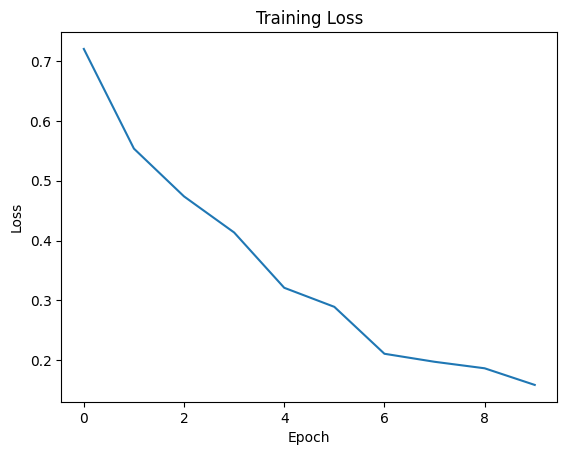

In [21]:
plt.plot(training_history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

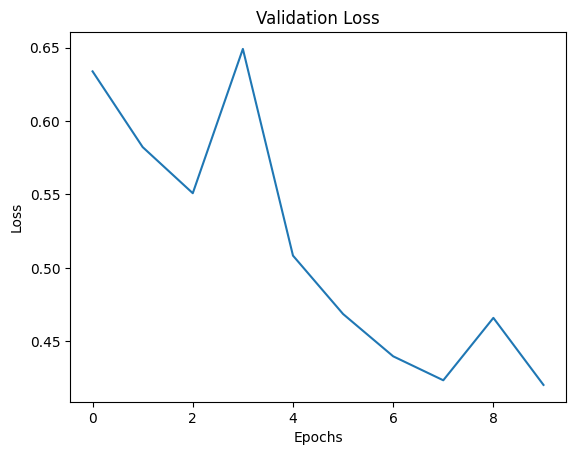

In [22]:
plt.plot(training_history['val_loss'])
plt.title("Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### Plot accuracy curves for training and validation sets

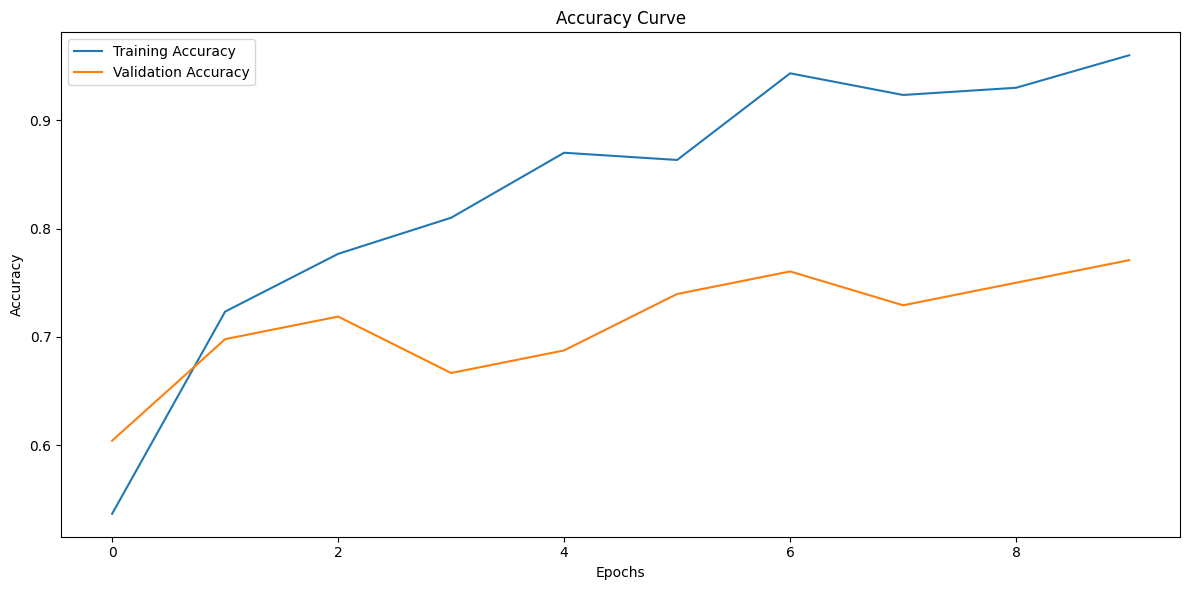

In [25]:
plt.figure(figsize=(12,6))
plt.plot(training_history['accuracy'], label = "Training Accuracy")
plt.plot(training_history['val_accuracy'], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.show()

## Image Captioning and Summarization using BLIP Pretrained Model

BLIP (Bootstrapping Language-Image Pretraining) is an advanced vision-and-language model designed to generate natural language descriptions for images. By leveraging both visual and textual information, BLIP can produce human-readable text that accurately reflects the content and context of an image. It is specifically trained to understand images and their relationships to summarizing text, making it ideal for tasks like image captioning, summarization, and visual question answering.

In this project, learners will utilize the BLIP model to build a system capable of automatically generating captions and summary for images. The code will integrate the BLIP model within a custom Keras layer. This allows the user to input an image and specify a task, either "caption" or "summary", to receive a textual output that describes or summarizes the content of the image.


#### Key Steps:

- **Image Loading and Preprocessing:** The code will begin by loading images from a file path, then converting and processing them into a format suitable for input to the BLIP model.
  
- **Text Generation:** Depending on the task, whether generating a caption or summary, the BLIP model will generate corresponding text based on the processed image.
  
- **Custom Keras Layer:** A custom Keras layer is a user-defined layer that extends Keras' built-in functionality.Here custom Keras layer will be implemented to wrap the BLIP model. This layer will handle the task-specific processing (captioning or summarizing) and integrate smoothly into a TensorFlow/Keras environment.


In [29]:
from PIL import Image
import tensorflow as tf
import numpy as np
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

## Loading BLIP Model

#### Load the BLIP Model and Processor from Hugging Face

Hugging Face is an open-source platform that provides pre-trained machine learning models, datasets, and tools, primarily focused on natural language processing, computer vision, and other AI tasks. It offers easy access to powerful models through its Transformers library.

- **BlipProcessor:** This handles the preprocessing of images and text. It converts images to the format that the BLIP model can understand.

- **BlipForConditionalGeneration:** This is the model itself, responsible for generating captions or summaries based on the processed image.


In [28]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

Loading weights: 100%|██████████| 473/473 [00:00<00:00, 18919.03it/s]
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when 

#### Custom Keras Layer: BlipCaptionSummaryLayer

Next, we define a custom `tf.keras.layers.Layer` class that takes in an image and a task input (either caption or summary) and processes the image using the BLIP model. To create a custom Keras layer, we need to subclass `tf.keras.layers.Layer` and implement the required methods.

#### **BlipCaptionSummaryLayer Class:**

This custom Keras layer integrates image preprocessing and text generation using a pretrained BLIP model.

- **`__init__`**: This constructor method initializes the `BlipCaptionSummaryLayer` class by setting up the BLIP processor and model.
  
- **`call`**: This method defines the operations or transformations applied to the input data as it passes through the layer.

 tf.py_function(...)
This is the most important part. Here's why it's needed:

BLIP runs in regular Python/PyTorch, but Keras operates in TensorFlow's computation graph — these two worlds don't naturally talk to each other.

tf.py_function acts as a bridge, allowing you to run plain Python code inside a TensorFlow graph.

- **`process_image`**: The `process_image` method contains the custom logic for loading the image, preprocessing it, generating the text (either a caption or a summary) using the BLIP model, and returning the generated result.


In [31]:
class BlipCaptionSummaryLayer(tf.keras.layers.Layer):
    
    def __init__ (self, processor,model, **args):
        
        super().__init__(**args)
        self.processor = processor
        self.model = model
        
    #The call() method is the heart of any Keras layer — it defines 
    # what happens when data actually passes through the layer during execution.
    
    def call(self, image_path, task):
        return tf.py_function(self.process_image, [image_path,task], tf.string)
    
    def process_image(self, image_path,task):
        
        try:
            #Convert image path into string
            image_path_str = image_path.numpy().decode("utf-8")
            
            # get image using image path and convert it into RGB
            image = Image.open(image_path_str).convert("RGB")
            
            # filter the task
            if task.numpy().decode("utf-8").lower() == "caption":
                prompt = "This is a picture of" # prompt for caption 
            elif task.numpy().decode("utf-8").lower() == "summary":
                prompt = "This is a detailed photo showing" # prompt for summary
            else:    
                print("invalid request!")
            
            #BLIP processor operation
            input = self.processor(images=image, text=prompt, return_tensors = "pt")
            
            # Blip model output
            output = self.model.generate(**input)     
            
            # convert output into string   
            result = self.processor.decode(output[0],skip_special_tokens = True)
            return result
    
        except Exception as e:
                # Handle errors during image processing or text generation
                print(f"Error: {e}")
                return "Error processing image"
        

## Task 8: Implement a Helper Function to Use the Custom Keras Layer

In this task, you will implement a helper function `generate_text` that utilizes the custom `BlipCaptionSummaryLayer` Keras layer to generate captions or summaries for a given image. The function will accept an image path and a task type (caption or summary), process the image using the BLIP model, and return the generated text.

### **Steps:**

#### Create the Helper Function `generate_text`:
The function will accept following parameters:

* **`image_path`**: The path to the image file (in tensor format).
* **`task`**: The type of task to perform, which can either be "caption" or "summary" (in tensor format).
  
Inside the function:
1. Create an instance(blip_layer) of the `BlipCaptionSummaryLayer`.
2. Call this layer with the provided image path and task type.
3. Return the generated caption or summary as the output.

**Note: Please copy and save the code of the task as it will be required for submission in the final project. Ensure to submit the response as part of your project submission**


In [32]:
def generate_text(image_path, task):
    blip_layer = BlipCaptionSummaryLayer(processor, blip_model)
    return blip_layer(image_path,task)

### Generate Captions and Summaries

Now we use the `generate_text` function to generate a caption and a summary for an image.
It processes the image and prints the corresponding text output in a human-readable format.
The function makes it easy to switch between generating captions and summaries based on the task type you provide.</br>
</br>

**Note:** Generated captions/summary may not always be accurate, as the model is limited by its training data and may not fully understand new or specific images.



In [34]:
image_path = tf.constant("aircraft_damage_dataset_v1/test/dent/144_10_JPG_jpg.rf.4d008cc33e217c1606b76585469d626b.jpg")

# Generate a caption for the image
caption = generate_text(image_path,tf.constant("caption"))
print("Caption: {}".format(caption.numpy().decode("utf-8")))

C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\transformers\generation\utils.py:1551: UserWarning: Using the model-agnostic default `max_length` (=26) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Caption: this is a picture of a plane


In [35]:
summary = generate_text(image_path, tf.constant("summary"))
print("Summary: {}".format(summary.numpy().decode("utf-8")))

C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\transformers\generation\utils.py:1551: UserWarning: Using the model-agnostic default `max_length` (=27) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Summary: this is a detailed photo showing the engine of a boeing 747


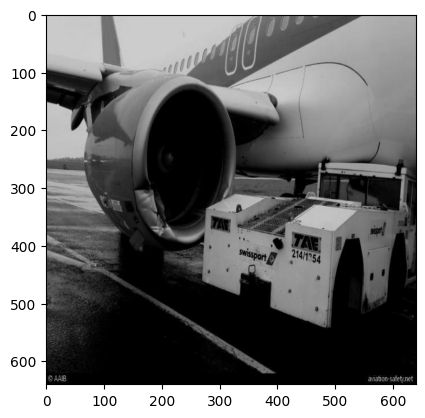

In [37]:
img_url = "aircraft_damage_dataset_v1/test/dent/144_10_JPG_jpg.rf.4d008cc33e217c1606b76585469d626b.jpg"
img = plt.imread(img_url)
plt.imshow(img)
plt.show()